# Libs

In [ ]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize


save_dir = "/home/gorka/overleaf/collective_rl_opts/figures/"
out_dir_single = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_8"






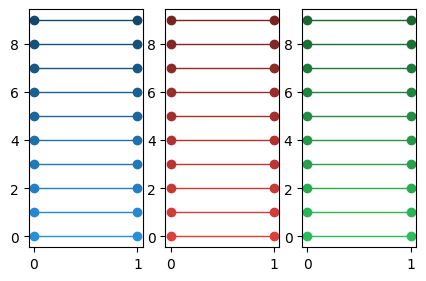

In [ ]:
colors = ['#2790DB', '#DB403D', '#2DBD59', '#a3a3a3', '#FFFFFF', '#000000']

cmap_blue_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[0], colors[-1]], N=250)  # N is the number of discrete colors
cmap_red_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[1], colors[-1]], N=250)  # N is the number of discrete colors
cmap_green_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[2], colors[-1]], N=250)  # N is the number of discrete colors
cmap_blue_red = LinearSegmentedColormap.from_list('custom_cmap', [colors[0], colors[1]], N=250)  # N is the number of discrete colors

# diverging version of your two-color map: colors[0] (R<1) -- white (R=1) -- colors[1] (R>1)
cmap_div = LinearSegmentedColormap.from_list('custom_div', [colors[0], 'white', colors[1]], N=250)

cmap_blue_white = LinearSegmentedColormap.from_list('custom_cmap', [colors[-2], colors[0]], N=250)  # N is the number of discrete colors


cmap_blue = LinearSegmentedColormap.from_list(
    "cmap_red_trunc",
    cmap_blue_full(np.linspace(0.0, 0.5, 256))
)

cmap_red = LinearSegmentedColormap.from_list(
    "cmap_red_trunc",
    cmap_red_full(np.linspace(0.0, 0.45, 256))
)

cmap_green = LinearSegmentedColormap.from_list(
    "cmap_green_trunc",
    cmap_green_full(np.linspace(0.0, 0.45, 256))
)

# Example
colors_from_cmap = cmap_blue(np.linspace(0, 0.4, 10))

golden_ratio = (1 + 5 ** 0.5) / 2  # Approximately 1.618
width = 5
height = width / golden_ratio

fig, axs = plt.subplots(1, 3, figsize=(width, height))

for cmap, ax in zip([cmap_blue, cmap_red, cmap_green], axs):
    colors_from_cmap = cmap(np.linspace(0, 1, 10))

    for i, color in enumerate(colors_from_cmap):
        ax.plot([0, 1], [i, i], 'o-',color=color, linewidth=1)


# Single agent policy

In [ ]:
out_dir_single = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_8"
taus = [2, 9] #np.arange(2,10)
episodes = 10000

[Text(0, 0.5, 'P(continue)'), 0.0, 1.1]

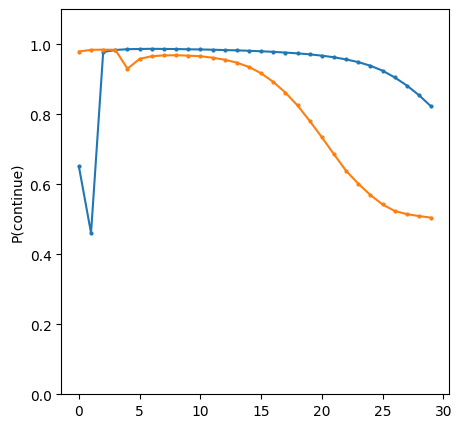

In [ ]:
fig_h, ax = plt.subplots(figsize=(5, 5))


for idx_vr, tau in enumerate(taus):

        file_name = f"_tau_{tau}_ep_{episodes}.npy"
        h_matrix_path = os.path.join(out_dir_single, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)
        p_keep = p_keep[:,:30]

        ax.plot(np.mean(p_keep, axis=0), '-o', ms=2, c=f'C{idx_vr}') 

        # Fill between with std
        # p_keep_std = np.std(p_keep, axis=0)
        # ax.fill_between(np.arange(p_keep.shape[-1]), 
        #                 np.mean(p_keep, axis=0) - p_keep_std,
        #                 np.mean(p_keep, axis=0) + p_keep_std,
        #                         color=f'C{idx_vr}', alpha=0.2)
        # ax.text(0.8, 0.1, fr'$\tau$ = '+str(tau), 
        #         transform=ax.transAxes, 
        #         ha='center', va='center', color=f'C{idx_vr}')

plt.setp(ax, ylabel = "P(continue)", ylim = (0, 1.1))


# Collective

In [ ]:
episodes = 10000
time_ep = 5000

num_agents = 50
tau_reward = 9

taus = np.arange(2, 10, 2)#[1, 5]
visual_ranges = np.arange(2, 12) 

shared_depletion = False
out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3/"

max_counter = 50
if 'agents' not in locals():
    from rl_opts.rl_framework.numba.agents import Foragers_efficient 
    agents = Foragers_efficient(num_agents, 2, np.array([max_counter, 2, 2]))

## Rewards

### Depletion time

In [ ]:
num_agents = 50
tau_reward = 9

rews_mean = np.zeros((len(taus), len(visual_ranges)))
rews_sem = np.zeros((len(taus), len(visual_ranges)))
rews_single = np.zeros(len(taus))

for idx_t, tau in enumerate(taus):
    for idx_vr, visual_range in enumerate(visual_ranges):
            
        file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes}.npy"
        
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        try:
            rews_run = np.load(rewards_path)/time_ep
        except:
            print(f"File not found: {rewards_path}")
            continue

        if len(rews_run.shape) > 3:
            rews_run = rews_run[:, idx_vr]


        rews_mean[idx_t, idx_vr] = rews_run[:, : , -500:].mean()

        rews_sem[idx_t, idx_vr] = rews_run[:, : , -500:].std() / np.sqrt(np.prod(rews_run.shape[:-1]))

    # Baselin Single
    rew_single_path = os.path.join(out_dir_single, f"rewards_tau_{tau}_ep_{episodes}.npy")   
    rews_single[idx_t] = (np.load(rew_single_path)[:, : , -50:]/time_ep).mean()

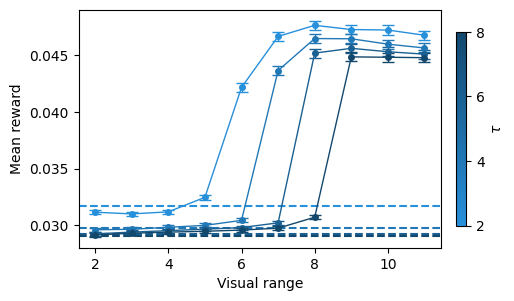

In [ ]:
fig, axs = plt.subplots(figsize=(width, height))

colors_from_cmap = cmap_blue(np.linspace(0, 1, len(taus)))
for idx_t, tau in enumerate(taus):
    axs.errorbar(visual_ranges, rews_mean[idx_t, :], yerr=rews_sem[idx_t, :], fmt='-o', ms=4, capsize=4, lw = 1, c = colors_from_cmap[idx_t])

    # Baseline
    plt.axhline(rews_single[idx_t], color='k', linestyle='--', label = 'Single agent', c = colors_from_cmap[idx_t])
    # axs.text(0.98, 0.12, fr'Single agent', transform=axs.transAxes, ha='right', va='center', color='k')

plt.setp(axs, xlabel = "Visual range", ylabel = "Mean reward")

# Restrict cmap_red to the same segment used for the plotted lines

sm = plt.cm.ScalarMappable(cmap=cmap_blue, norm=plt.Normalize(vmin=taus[0], vmax=taus[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.025, pad=0.04)
cbar.set_label(r"$\tau$")
cbar.set_ticks(np.linspace(taus[0], taus[-1], num=len(taus)))
cbar.set_ticklabels([str(t) for t in taus])

### Tag time

In [ ]:
episodes = 10000
time_ep = 5000

num_agents = 50
tau = 2

taus_reward = np.arange(1, 6)#[1, 5]
visual_ranges = np.arange(2, 12) 

shared_depletion = False
out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3/"

max_counter = 50
if 'agents' not in locals():
    from rl_opts.rl_framework.numba.agents import Foragers_efficient 
    agents = Foragers_efficient(num_agents, 2, np.array([max_counter, 2, 2]))

In [ ]:
rews_mean_tauR = np.zeros((len(taus_reward), len(visual_ranges)))
rews_sem_tauR = np.zeros((len(taus_reward), len(visual_ranges)))

for idx_t, tau_reward in enumerate(taus_reward):
    for idx_vr, visual_range in enumerate(visual_ranges):
            
        file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes}.npy"
        
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        try:
            rews_run = np.load(rewards_path)/time_ep
        except:
            print(f"File not found: {rewards_path}")
            continue

        if len(rews_run.shape) > 3:
            rews_run = rews_run[:, idx_vr]

        

        rews_mean_tauR[idx_t, idx_vr] = rews_run[:4, : , -500:].mean()

        rews_sem_tauR[idx_t, idx_vr] = rews_run[:4, : , -500:].std() / np.sqrt(np.prod(rews_run.shape[:-1]))

# Baselin Single
rew_single_path = os.path.join(out_dir_single, f"rewards_tau_{tau}_ep_{episodes}.npy")   
rews_single_tauR = (np.load(rew_single_path)[:, : , -500:]/time_ep).mean()

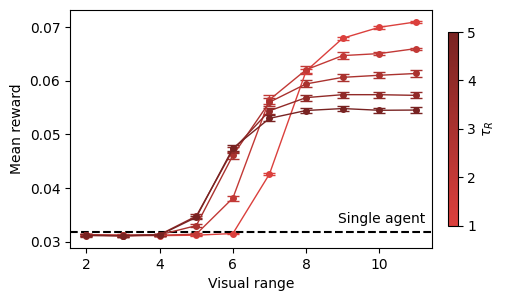

In [ ]:
fig, axs = plt.subplots(figsize=(width, height))


colors_from_cmap = cmap_red(np.linspace(0, 1, len(taus_reward)))
for idx_t, tau_reward in enumerate(taus_reward):
    axs.errorbar(visual_ranges, rews_mean_tauR[idx_t, :], yerr=rews_sem_tauR[idx_t, :], fmt='-o', ms=4, capsize=4, lw = 1, c = colors_from_cmap[idx_t])

# Baseline
plt.axhline(rews_single_tauR, color='k', linestyle='--', label = 'Single agent')
axs.text(0.98, 0.12, fr'Single agent', transform=axs.transAxes, ha='right', va='center', color='k')

plt.setp(axs, xlabel = "Visual range", ylabel = "Mean reward")

sm = plt.cm.ScalarMappable(cmap=cmap_red, norm=plt.Normalize(vmin=taus_reward[0], vmax=taus_reward[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.025, pad=0.04)
cbar.set_label(r"$\tau_R$")
cbar.set_ticks(np.linspace(taus_reward[0], taus_reward[-1], num=len(taus_reward)))
cbar.set_ticklabels([str(t) for t in taus_reward])

### Together

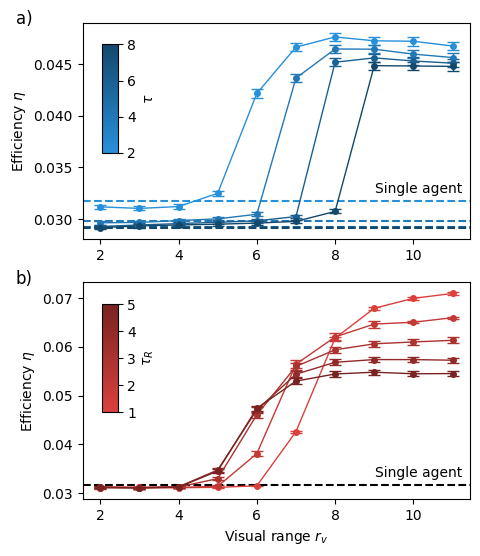

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(width, 2*height))

####### TAU #######
colors_from_cmap = cmap_blue(np.linspace(0, 1, len(taus)))
for idx_t, tau in enumerate(taus):
    axs[0].errorbar(visual_ranges, rews_mean[idx_t, :], yerr=rews_sem[idx_t, :], fmt='-o', ms=4, capsize=4, lw = 1, c = colors_from_cmap[idx_t])

    # Baseline
    axs[0].axhline(rews_single[idx_t], color='k', linestyle='--', label = 'Single agent', c = colors_from_cmap[idx_t])

axs[1].text(0.98, 0.2, fr'Single agent', transform=axs[0].transAxes, ha='right', va='bottom', color='k')


# Colorbar
axins = axs[0].inset_axes([0.05, 0.4, 0.04, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap_blue, norm=plt.Normalize(vmin=taus[0], vmax=taus[-1]))
cbar = fig.colorbar(sm, cax=axins, orientation='vertical')
cbar.set_label(r"$\tau$")
cbar.set_ticks(np.linspace(taus[0], taus[-1], num=len(taus)))
cbar.set_ticklabels([str(t) for t in taus])



####### TAU_R ####### 
colors_from_cmap = cmap_red(np.linspace(0, 1, len(taus_reward)))
for idx_t, tau_reward in enumerate(taus_reward):
    axs[1].errorbar(visual_ranges, rews_mean_tauR[idx_t, :], yerr=rews_sem_tauR[idx_t, :], fmt='-o', ms=4, capsize=4, lw = 1, c = colors_from_cmap[idx_t])

# Baseline
axs[1].axhline(rews_single_tauR, color='k', linestyle='--', label = 'Single agent')
axs[1].text(0.98, 0.12, fr'Single agent', transform=axs[1].transAxes, ha='right', va='center', color='k')

# Colorbar
axins = axs[1].inset_axes([0.05, 0.4, 0.04, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap_red, norm=plt.Normalize(vmin=taus_reward[0], vmax=taus_reward[-1]))
cbar = fig.colorbar(sm, cax=axins, orientation='vertical')
cbar.set_label(r"$\tau_R$")
cbar.set_ticks(np.linspace(taus_reward[0], taus_reward[-1], num=len(taus_reward)))
cbar.set_ticklabels([str(t) for t in taus_reward])



####### General #######
plt.setp(axs[1], xlabel = r"Visual range $r_v$")
plt.setp(axs, ylabel = r"Efficiency $\eta$")
# axs[0].set_ylabel("Mean reward per step")

# add labels a and b to panels
for i, ax in enumerate(axs):
    ax.text(-0.13, 1.06, chr(97 + i) + ")", transform=ax.transAxes, fontsize=12, va='top', ha='right')



fig.savefig(save_dir + "rewards.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

## H-matrices

''

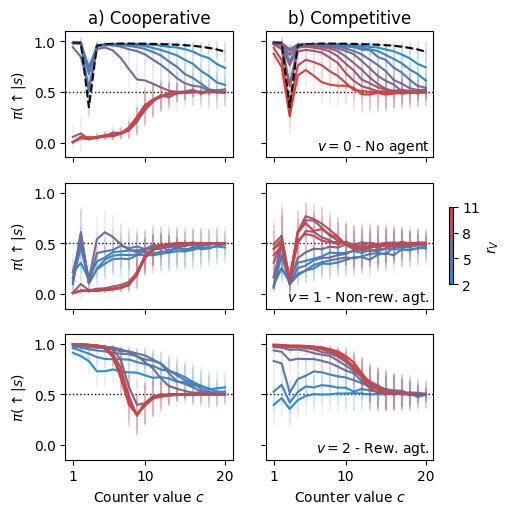

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(width, 1.8*height), sharex=True, sharey = True)

tau = 4; tau_reward = 9 
# get colors from cmap
colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(visual_ranges)))

counter_max = 20

for idx_s, shared_depletion in enumerate([False, True]):

    title = "a) Cooperative" if not shared_depletion else "b) Competitive"
    axs[0, idx_s].set_title(title)

    for idx_vr, visual_range in enumerate(visual_ranges):
        
        file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes}.npy"
                
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)

        try:
        
            mats = np.load(h_matrix_path)
        except: 
            pass

        
        if len(mats.shape) > 4:
            mats = mats[:, idx_vr]
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)

        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if idx_vr == 0:
                    if cone_val == 0 and rew_val == 0:
                        title = r"$v=0$ - No agent"
                    if cone_val == 1 and rew_val == 0:
                        title = r"$v=1$ - Non-rew. agt."
                    if cone_val == 1 and rew_val == 1:
                        title = r"$v=2$ - Rew. agt."

                    if cone_val == 0 and rew_val == 1 or idx_s == 0:  
                        pass
                    else:                      
                        axs[cone_val+rew_val, idx_s].text(0.98, 0.02, title, transform=axs[cone_val+rew_val, idx_s].transAxes, ha='right', va='bottom', fontsize=10)

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)
                idxs = idxs[:counter_max]
                

                axs[cone_val+rew_val, idx_s].plot(np.mean(p_keep[:, idxs], axis=0),
                                                color=colors_from_cmap[idx_vr]) 
                axs[cone_val+rew_val, idx_s].errorbar(np.arange(max_counter)[:counter_max], 
                                                      np.mean(p_keep[:, idxs], axis=0),
                                                      yerr=np.std(p_keep[:, idxs], axis=0),
                                                      color=colors_from_cmap[idx_vr], alpha = 0.1) 
                
for a in axs.flatten():
     a.axhline(0.5, color='k', linestyle=':', lw=1, zorder = -1)
                
            
# Single agent baseline
mats_single= np.load(os.path.join(out_dir_single, f"h_matrix_tau_{tau}_ep_{episodes}.npy"))
hflat = mats_single.reshape(-1, 2, mats_single.shape[-1])
p_keep = hflat[:, 0, :] / hflat.sum(1)
p_keep = p_keep[:,:counter_max]

for ax in axs[0,:]:
    ax.plot(np.mean(p_keep, axis=0),  ls = '--', c='k') 

    ax.errorbar(np.arange(max_counter)[:p_keep.shape[1]], 
                np.mean(p_keep, axis=0),
                yerr=np.std(p_keep, axis=0),
                color='k', alpha = 0.1) 


sm = plt.cm.ScalarMappable(cmap=cmap_blue_red, norm=plt.Normalize(vmin=visual_ranges[0], vmax=visual_ranges[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.01, pad=0.04)
cbar.set_label(r"$r_V$")
cbar.set_ticks(np.linspace(visual_ranges[0], visual_ranges[-1], num=4))
# cbar.set_ticklabels([str(t) for t in visual_ranges[::2]])

plt.setp(axs[:,0], ylabel = r"$\pi(\uparrow | s)$")
plt.setp(axs[-1,:], xlabel = r"Counter value $c$", xticks = [0,9,19], xticklabels = [1,10,20])
    
fig.savefig(save_dir + "hmats_both_cases.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)
;

In [ ]:
idxs

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

<ErrorbarContainer object of 3 artists>

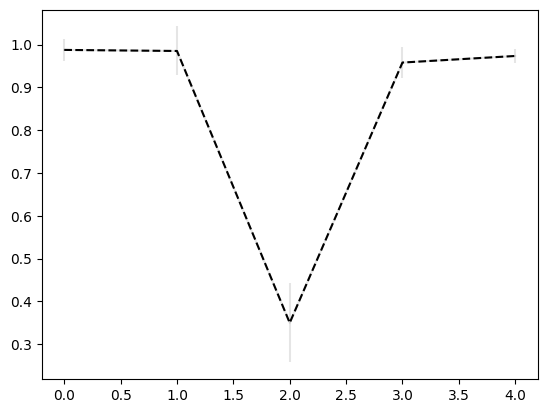

In [ ]:
plt.plot(np.mean(p_keep, axis=0),  ls = '--', c='k') 

plt.errorbar(np.arange(max_counter)[:p_keep.shape[1]], 
                np.mean(p_keep, axis=0),
                yerr=np.std(p_keep, axis=0),
                color='k', alpha = 0.1) 

## Aggregation

### Depletion time + Trajectories

#### Depletion

In [ ]:
tau_reward = 9
visual_ranges = np.arange(2, 13) 
taus = np.arange(2, 12)
taus_th = np.arange(1, 13)
num_agents = 50

path_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"


Nts = [20, 100] #[20, 50, 100]
avg_cr_idx = np.ones((len(Nts), len(taus), len(visual_ranges)))
std_cr_idx = np.zeros((len(Nts), len(taus), len(visual_ranges)))

shared_depletion = False
time_ep = 15000
episodes_learning = 10000

for idx_Nt, Nt in enumerate(Nts):

    if Nt == 100:
        out_dir = os.path.join(path_dir, f"exp_7_3")
    else:
        out_dir = os.path.join(path_dir, f"exp_7_4")
    out_dir_results = os.path.join(out_dir, f"results")
    
    for idx_tr, tau in enumerate((taus)):        
        for idx_vr, visual_range in enumerate(visual_ranges):

            if Nt == 100:
                file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}.npy"
            else:
                file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"
                
            cr_runs = np.load(os.path.join(out_dir_results, f"cr_runs"+file_results))
            
            avg_cr_idx[idx_Nt, idx_tr, idx_vr] = cr_runs.mean()
            std_cr_idx[idx_Nt, idx_tr, idx_vr] = cr_runs.std() 

[Text(0.5, 0, 'Visual range $v_r$'), Text(0.5, 0, 'Visual range $v_r$')]

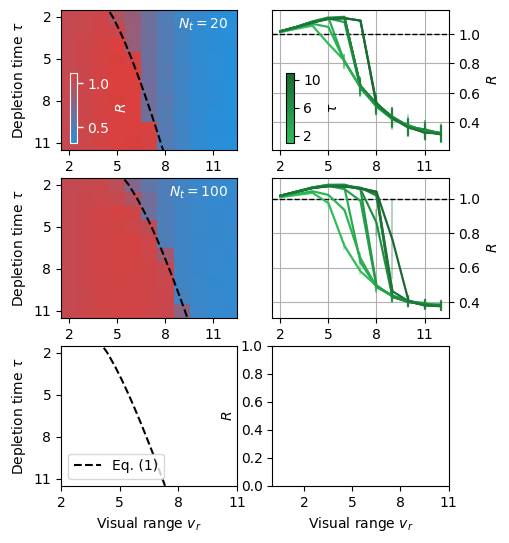

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(1*width, 2*height))

# Use one global scale so colors are comparable across panels
vmin = np.min(avg_cr_idx)
vmax = np.max(avg_cr_idx)

ims = []
for idx_Nt, Nt in enumerate(Nts):
    
    im = ax[idx_Nt, 0].matshow(avg_cr_idx[idx_Nt], vmin=vmin, vmax=vmax, aspect = 'auto', cmap=cmap_blue_red, zorder = -10)
    ims.append(im)
    ax[idx_Nt, 0].xaxis.set_ticks_position('bottom')

    ax[idx_Nt, 0].text(0.95, 0.95, fr"$N_t = ${Nt}", transform=ax[idx_Nt, 0].transAxes, ha='right', va = 'top', c = 'w')

axins = ax[0, 0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ims[0], cax=axins, orientation='vertical')
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$', color='white')



colors_from_cmap = cmap_green(np.linspace(0, 1, len(taus)))
for idx_Nt, Nt in enumerate(Nts):

    ax[idx_Nt, 1].axhline(1, color='k', linestyle='--', lw=1)
    for idx_tr, tau in enumerate(taus):
        ax[idx_Nt, 1].errorbar(visual_ranges, avg_cr_idx[idx_Nt, idx_tr], 
                               yerr=std_cr_idx[idx_Nt, idx_tr], color=colors_from_cmap[idx_tr],
                               alpha = 0.3)

        ax[idx_Nt, 1].plot(visual_ranges, avg_cr_idx[idx_Nt, idx_tr], color=colors_from_cmap[idx_tr])

        ax[idx_Nt, 1].yaxis.set_label_position("right")
        ax[idx_Nt, 1].yaxis.tick_right()

    


    ax[idx_Nt, 1].grid()

axins = ax[0, 1].inset_axes([0.08, 0.05, 0.04, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap_green, norm=plt.Normalize(vmin=1, vmax=11))
cbar = fig.colorbar(sm, cax=axins, orientation='vertical')
cbar.set_label(r"$\tau$")
cbar.set_ticks(np.arange(2, 11, 4))
cbar.set_ticklabels([str(t) for t in taus[::4]])


# Theoretical predictions
ax[0,0].plot(VR_prob(taus_th, l = 5, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--')

ax[1,0].plot(VR_prob(taus_th, l = 8, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--')

ax[2,0].plot(VR_prob(taus_th, l = 4, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--', label = 'Eq. (1)')
ax[2,0].legend(loc = 'lower left')





plt.setp(ax[:,1],   
        xticks= visual_ranges[::3],
        ylabel = r"$R$"
         )


plt.setp(ax[:,0],          
         xticks=np.arange(len(visual_ranges))[::3], xticklabels=visual_ranges[::3],
        yticks=np.arange(len(taus))[::3], yticklabels=taus[::3],
         ylim = (len(taus)-0.5, -0.5),
         ylabel = r"Depletion time $\tau$"
         )

plt.setp(ax[-1,:],
         xlabel = r"Visual range $v_r$")


# fig.savefig(save_dir + "CR_tau.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

#### Trajectories

In [ ]:
pos_s = np.load('data_figures_paper/posr_single.npy')
target_s = np.load('data_figures_paper/targets_single.npy')
pos_c = np.load('data_figures_paper/posr_collective.npy')
target_c = np.load('data_figures_paper/targets_collective.npy')
L = 50; r = 0.5

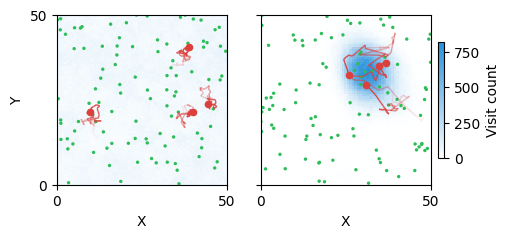

In [ ]:

from matplotlib.patches import Circle
from matplotlib.collections import LineCollection

bins = np.linspace(0, L, 70)
h_s, _, _ = np.histogram2d(pos_s[..., 0].flatten(), pos_s[..., 1].flatten(), bins=bins)
h_c, _, _ = np.histogram2d(pos_c[..., 0].flatten(), pos_c[..., 1].flatten(), bins=bins)
vmax = max(h_s.max(), h_c.max())

fig, ax = plt.subplots(1, 2, figsize=(width, 1.8*height/3*2), sharey=True, sharex=True)


##### SINGLE

ax[0].hist2d(pos_s[..., 0].flatten(), pos_s[..., 1].flatten(), bins=bins, cmap=cmap_blue_white, alpha=1, vmin=0, vmax=vmax)

for t in target_s:
    ax[0].add_patch(Circle(t, radius=r, color=colors[2], linewidth=0, alpha=1))

t_a = 50
opaque = 1
for idx_a in [1, 2, 5, 7]:
    pts = pos_s[idx_a, -t_a:, :]
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    alphas = np.concatenate((np.linspace(0, 1, len(segs)-opaque), np.ones(opaque)))
    lc = LineCollection(segs, color=colors[1], alpha=alphas, linewidth=1)
    ax[0].add_collection(lc)
    ax[0].scatter(pos_s[idx_a, -1, 0], pos_s[idx_a, -1, 1], color=colors[1], s=20)



##### COLLECTIVE

im = ax[1].hist2d(pos_c[..., 0].flatten(), pos_c[..., 1].flatten(), bins=bins, cmap=cmap_blue_white, vmin=0, vmax=vmax)[3]

for t in target_c:
    ax[1].add_patch(Circle(t, radius=r, color=colors[2], linewidth=0, alpha=1))

t_a = 50
opaque = 1
for idx_a in [0, 4, 9, 21]:
    pts = pos_c[idx_a, -t_a:, :]
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    alphas = np.concatenate((np.linspace(0, 1, len(segs)-opaque), np.ones(opaque)))
    lc = LineCollection(segs, color=colors[1], alpha=alphas, linewidth=1)
    ax[1].add_collection(lc)
    ax[1].scatter(pos_c[idx_a, -1, 0], pos_c[idx_a, -1, 1], color=colors[1], s=20)


fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.015, pad=0.02, label = "Visit count")
ax[0].set_ylabel("Y")
plt.setp(ax, xlim=(0, L), ylim=(0, L), aspect='equal', xticks=[0, L], yticks=[0, L], xlabel="X");


In [ ]:
np.random.randn(10000) + pos_c[..., 0].flatten().mean()

np.float64(31.511977590850545)

In [ ]:
pos_c[..., 0].flatten()

array([33.84004919, 32.84237319, 31.84469719, ..., 31.26128743,
       30.46571445, 29.67014147])

(array([0.00098175, 0.00687224, 0.01996222, 0.03468845, 0.05792317,
        0.07003141, 0.06970416, 0.03926995, 0.02094397, 0.00687224]),
 array([14.84858672, 17.90435861, 20.9601305 , 24.01590239, 27.07167428,
        30.12744617, 33.18321806, 36.23898995, 39.29476183, 42.35053372,
        45.40630561]),
 <BarContainer object of 10 artists>)

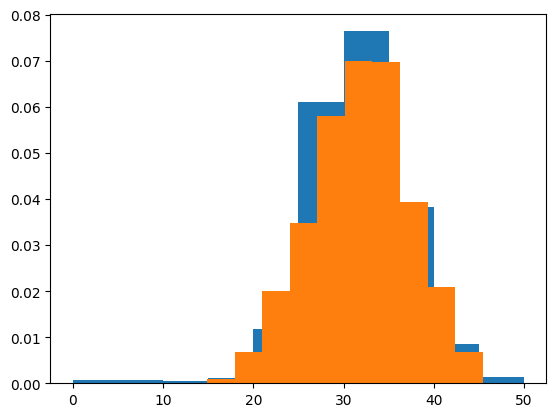

In [ ]:
x = pos_c[..., 0].flatten()
y = np.random.randn(1000) * x.std() + x.mean()

plt.hist(x, density = True)
plt.hist(y, density = True)

In [ ]:
np.random.randn()

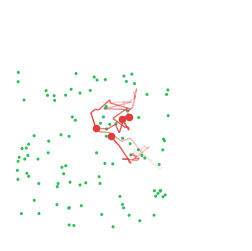

In [ ]:
fig, ax = plt.subplots(figsize = (3, 3))
bins = 100
# ax.hist2d(pos_c[..., 0].flatten(), pos_c[..., 1].flatten(), bins=bins, cmap=cmap_blue_white, vmin=0, vmax=vmax)[3]

im = ax.hist2d(np.random.randn(10000)*10 + pos_c[..., 0].flatten().mean(), 
          np.random.randn(10000)*10 + pos_c[..., 1].flatten().mean(), bins=bins, cmap=cmap_blue_white, vmin=0, vmax=vmax)[3]



for t in target_c:
    ax.add_patch(Circle(t, radius=r, color=colors[2], linewidth=0, alpha=1))

t_a = 50
opaque = 1
for idx_a in [0, 4, 9, 21]:
    pts = pos_c[idx_a, -t_a:, :]
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    alphas = np.concatenate((np.linspace(0, 1, len(segs)-opaque), np.ones(opaque)))
    lc = LineCollection(segs, color=colors[1], alpha=alphas, linewidth=1)
    ax.add_collection(lc)
    ax.scatter(pos_c[idx_a, -1, 0], pos_c[idx_a, -1, 1], color=colors[1], s=20)


ax.set_axis_off()


#### Together

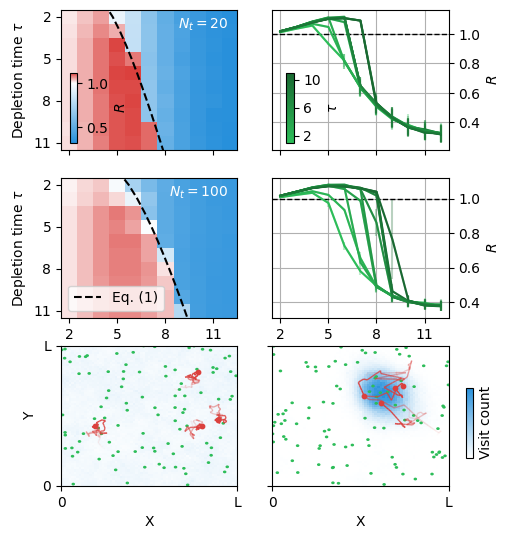

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(width, 2*height))#figsize=(2*width, 3*height))

# Use one global scale so colors are comparable across panels
vmin = np.min(avg_cr_idx)
vmax = np.max(avg_cr_idx)

p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)


ims = []
for idx_Nt, Nt in enumerate(Nts):
    
    im = ax[idx_Nt, 0].matshow(avg_cr_idx[idx_Nt], cmap=cmap_div, norm=norm, aspect = 'auto', zorder = -10)
    ims.append(im)
    ax[idx_Nt, 0].xaxis.set_ticks_position('bottom')

    ax[idx_Nt, 0].text(0.95, 0.95, fr"$N_t = ${Nt}", transform=ax[idx_Nt, 0].transAxes, 
                       ha='right', va = 'top', c = 'w')

axins = ax[0, 0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ims[0], cax=axins, orientation='vertical')
# cbar.outline.set_edgecolor('white')
# cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$', color='k')



colors_from_cmap = cmap_green(np.linspace(0, 1, len(taus)))
for idx_Nt, Nt in enumerate(Nts):

    ax[idx_Nt, 1].axhline(1, color='k', linestyle='--', lw=1)
    for idx_tr, tau in enumerate(taus):
        ax[idx_Nt, 1].errorbar(visual_ranges, avg_cr_idx[idx_Nt, idx_tr], 
                               yerr=std_cr_idx[idx_Nt, idx_tr], color=colors_from_cmap[idx_tr],
                               alpha = 0.3)

        ax[idx_Nt, 1].plot(visual_ranges, avg_cr_idx[idx_Nt, idx_tr], color=colors_from_cmap[idx_tr])

        ax[idx_Nt, 1].yaxis.set_label_position("right")
        ax[idx_Nt, 1].yaxis.tick_right()

    


    ax[idx_Nt, 1].grid()

axins = ax[0, 1].inset_axes([0.08, 0.05, 0.04, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap_green, norm=plt.Normalize(vmin=1, vmax=11))
cbar = fig.colorbar(sm, cax=axins, orientation='vertical')
cbar.set_label(r"$\tau$")
cbar.set_ticks(np.arange(2, 11, 4))
cbar.set_ticklabels([str(t) for t in taus[::4]])


# Theoretical predictions
ax[0,0].plot(VR_prob(taus_th, l = 5, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--')

ax[1,0].plot(VR_prob(taus_th, l = 8, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--', label = 'Eq. (1)')
ax[1,0].legend(loc = 'lower left')





plt.setp(ax[:-1,1],   
        xticks= visual_ranges[::3],
        ylabel = r"$R$"
         )


plt.setp(ax[:-1,0],          
         xticks=np.arange(len(visual_ranges))[::3], xticklabels=visual_ranges[::3],
        yticks=np.arange(len(taus))[::3], yticklabels=taus[::3],
         ylim = (len(taus)-0.5, -0.5),
         ylabel = r"Depletion time $\tau$"
         )

plt.setp(ax[-2,:],
         xlabel = r"Visual range $r_v$")

plt.setp(ax[0,:], xticklabels = []);


################################################# TRAJECTORIES ########################################################
ax_traj = ax[-1]

bins = np.linspace(0, L, 70)
h_s, _, _ = np.histogram2d(pos_s[..., 0].flatten(), pos_s[..., 1].flatten(), bins=bins)
h_c, _, _ = np.histogram2d(pos_c[..., 0].flatten(), pos_c[..., 1].flatten(), bins=bins)
vmax = max(h_s.max(), h_c.max())

##### SINGLE

ax_traj[0].hist2d(pos_s[..., 0].flatten(), pos_s[..., 1].flatten(), bins=bins, cmap=cmap_blue_white, alpha=1, vmin=0, vmax=vmax, rasterized =True)

for t in target_s:
    ax_traj[0].add_patch(Circle(t, radius=r, color=colors[2], linewidth=0, alpha=1))

t_a = 50
opaque = 1
for idx_a in [1, 2, 5, 7]:
    pts = pos_s[idx_a, -t_a:, :]
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    alphas = np.concatenate((np.linspace(0, 1, len(segs)-opaque), np.ones(opaque)))
    lc = LineCollection(segs, color=colors[1], alpha=alphas, linewidth=1)
    ax_traj[0].add_collection(lc)
    ax_traj[0].scatter(pos_s[idx_a, -1, 0], pos_s[idx_a, -1, 1], color=colors[1], s=10)



##### COLLECTIVE

ax_traj[1].hist2d(pos_c[..., 0].flatten(), pos_c[..., 1].flatten(), bins=bins, cmap=cmap_blue_white, vmin=0, vmax=vmax, rasterized =True)

for t in target_c:
    ax_traj[1].add_patch(Circle(t, radius=r, color=colors[2], linewidth=0, alpha=1))

t_a = 50
opaque = 1
for idx_a in [0, 4, 9, 21]:
    pts = pos_c[idx_a, -t_a:, :]
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    alphas = np.concatenate((np.linspace(0, 1, len(segs)-opaque), np.ones(opaque)))
    lc = LineCollection(segs, color=colors[1], alpha=alphas, linewidth=1)
    ax_traj[1].add_collection(lc)
    ax_traj[1].scatter(pos_c[idx_a, -1, 0], pos_c[idx_a, -1, 1], color=colors[1], s=10)



axins = ax[-1, -1].inset_axes([1.1, 0.2, 0.04, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap_blue_white, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, cax=axins, orientation='vertical')
cbar.set_label(r"Visit count")
cbar.set_ticks([])



plt.setp(ax_traj, xlim=(0, L), ylim=(0, L), xticks=[0, L], xticklabels = [0,'L'], yticks=[0, L], xlabel="X");
ax_traj[0].set(yticklabels = [0,'L'], ylabel="Y")
ax_traj[1].set(yticklabels = [], ylabel="")

fig.savefig(save_dir + "CR_tau_dev.svg", pad_inches = 0, bbox_inches = 'tight', transparent=True)

### Tag time + Fraction learning

#### Tag time


In [ ]:
num_agents = 25
Nt = 100
tau = 2
taus_reward = np.arange(2, 23) # for most we only have: np.arange(2, 10), for num_agents = 25 and tau = 2, we have np.arange(2, 23)
visual_ranges = np.arange(2, 13) 

out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3"
out_dir_results = os.path.join(out_dir, f"results")
os.makedirs(out_dir_results, exist_ok=True)


time_ep = 15000
save_position_from_ep = time_ep - 5000
episodes_learning = 10000


avg_cr_idx_tag = np.ones((2, len(taus_reward), len(visual_ranges)))
std_cr_idx_tag = np.ones((2, len(taus_reward), len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([False, True]):    
    

    for idx_tr, tau_reward in enumerate((taus_reward)):
        for idx_vr, visual_range in enumerate((visual_ranges)):


            file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"

            try:    
                cr_runs = np.load(os.path.join(out_dir_results, f"cr_runs"+file_results))                         
                avg_cr_idx_tag[idx_sd, idx_tr, idx_vr] = cr_runs.mean()
                std_cr_idx_tag[idx_sd, idx_tr, idx_vr] = cr_runs.std()
            except:
                pass

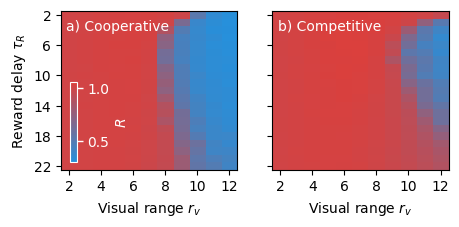

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(width, 2*height/3), sharey=True)

vmin = np.min(avg_cr_idx_tag)
vmax = np.max(avg_cr_idx_tag)



for idx_sd, shared_depletion in enumerate([False, True]):

    ax[idx_sd].matshow(avg_cr_idx_tag[idx_sd], aspect = 'auto', vmin=vmin, vmax=vmax, cmap=cmap_blue_red)
    ax[idx_sd].xaxis.set_ticks_position('bottom')

    ax[idx_sd].text(0.03, 0.95, 'b) Competitive' if shared_depletion else 'a) Cooperative',
                     transform=ax[idx_sd].transAxes, ha='left', va='top', c = 'w')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2], 
         yticks=np.arange(len(taus_reward))[::4], yticklabels=taus_reward[::4],
         xlabel = r"Visual range $r_v$"
         )
plt.setp(ax[0], ylabel = r"Reward delay $\tau_R$")

# add colorbar to both subplots
# cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)

axins = ax[0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ax[0].images[0], cax=axins, orientation='vertical')
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$', color='white')



# fig.savefig(save_dir + "CR_tauR.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

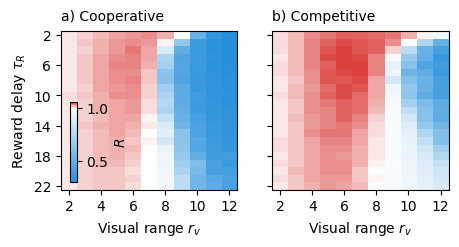

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(width, 2*height/3), sharey=True)

vmin = np.min(avg_cr_idx_tag)
vmax = np.max(avg_cr_idx_tag)

vmin, vmax = float(avg_cr_idx_tag.min()), float(avg_cr_idx_tag.max())
p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)

for idx_sd, shared_depletion in enumerate([False, True]):

    ax[idx_sd].matshow(avg_cr_idx_tag[idx_sd], aspect = 'auto', cmap=cmap_div, norm=norm)
    ax[idx_sd].xaxis.set_ticks_position('bottom')

    ax[idx_sd].text(0.0, 1.05, 'b) Competitive' if shared_depletion else 'a) Cooperative',
                     transform=ax[idx_sd].transAxes, ha='left', va='bottom', c = 'k')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2], 
         yticks=np.arange(len(taus_reward))[::4], yticklabels=taus_reward[::4],
         xlabel = r"Visual range $r_v$"
         )
plt.setp(ax[0], ylabel = r"Reward delay $\tau_R$")

# add colorbar to both subplots
# cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)

axins = ax[0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ax[0].images[0], cax=axins, orientation='vertical')
# cbar.outline.set_edgecolor('k')
# cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$')#, color='white')



fig.savefig(save_dir + "CR_tauR.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

#### Fraction of learning agents

In [ ]:
out_dir_results_frac_1 = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_4/results"
out_dir_results_frac = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_7/results"

fractions = np.arange(0.1, 1.1, 0.1)
tau = 4
tau_reward = 9
visual_ranges = np.arange(2, 13) 
num_agents = 50
episodes_learning = 10000
Nt = 20


L = 50; r = 0.5; agent_step = 1

In [ ]:
avg_cr_frac = np.ones((len(fractions), len(visual_ranges)))   

shared_depletion = False

for idx_f, fraction in enumerate(tqdm(fractions)):    
    for idx_vr, visual_range in enumerate((visual_ranges)):

        if fraction == 1:
            file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{15000}_Nt_{Nt}.npy"
        else:
            file_results = f"_shared_{shared_depletion}_frac_{fraction}_numag_{num_agents}_L_{L}_Nt_{Nt}_tau_{tau}_tauR_{tau_reward}_vr_{visual_ranges[idx_vr]}_ep_{episodes_learning}_simul_to_{5000}_rpr_{True}.npy"

        try:
            if fraction == 1:
                cr_runs = np.load(os.path.join(out_dir_results_frac_1, f"cr_runs"+file_results))
            else:
                cr_runs = np.load(os.path.join(out_dir_results_frac, f"cr_runs"+file_results))
        except:
            continue

        avg_cr_frac[idx_f, idx_vr] = cr_runs.mean()
            

  0%|          | 0/10 [00:00<?, ?it/s]

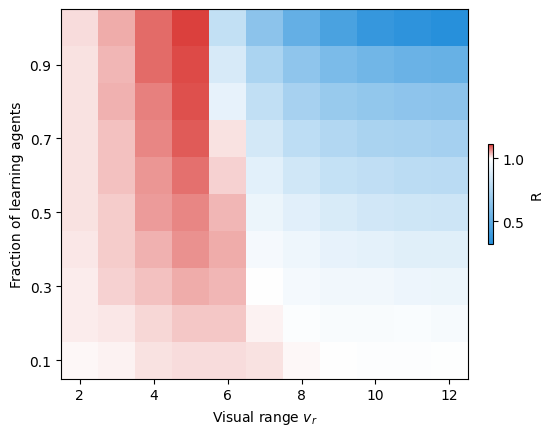

In [ ]:
fig, ax = plt.subplots()


vmin, vmax = float(avg_cr_frac.min()), float(avg_cr_frac.max())
p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)

im = ax.matshow(avg_cr_frac, cmap=cmap_div, norm=norm)

ax.xaxis.set_ticks_position('bottom')

cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
cb.set_label('R')

plt.setp(ax,
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2],
         yticks=np.arange(len(fractions))[::2], yticklabels=np.round(fractions[::2],1),
         xlabel="Visual range $v_r$", ylabel=r"Fraction of learning agents",
         ylim=(-0.5, len(fractions)-0.5));     # 0.1 at bottom

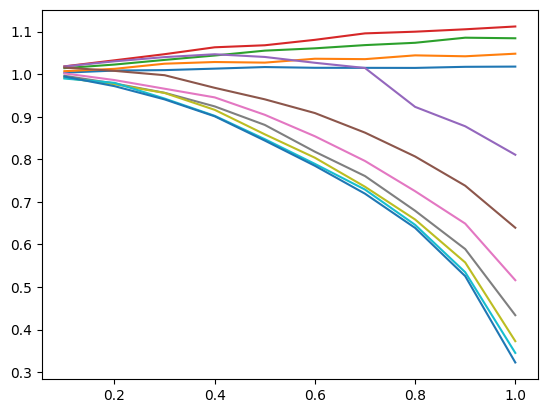

In [ ]:
for i in range(len(visual_ranges)):
    plt.plot(fractions, avg_cr_frac[:,i])

#### Together

Text(0.0, 1.05, 'c) Frac. learning agents')

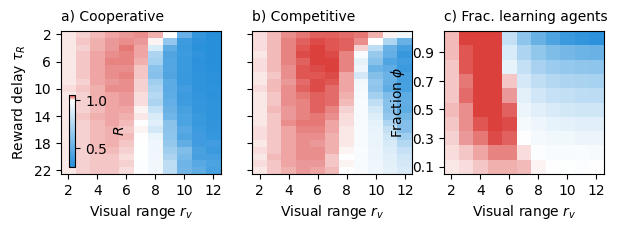

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(1.4*width, 1.8*height/3))

vmin = np.min(avg_cr_idx_tag)
vmax = np.max(avg_cr_idx_tag)

vmin, vmax = float(avg_cr_idx_tag.min()), float(avg_cr_idx_tag.max())
p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)

for idx_sd, shared_depletion in enumerate([False, True]):

    ax[idx_sd].matshow(avg_cr_idx_tag[idx_sd], aspect = 'auto', cmap=cmap_div, norm=norm)
    ax[idx_sd].xaxis.set_ticks_position('bottom')

    ax[idx_sd].text(0.0, 1.05, 'b) Competitive' if shared_depletion else 'a) Cooperative',
                     transform=ax[idx_sd].transAxes, ha='left', va='bottom', c = 'k')

plt.setp(ax[:-1], 
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2], 
         yticks=np.arange(len(taus_reward))[::4], yticklabels=taus_reward[::4],
         xlabel = r"Visual range $r_v$"
         )
plt.setp(ax[0], ylabel = r"Reward delay $\tau_R$")
plt.setp(ax[1], yticklabels = [])

axins = ax[0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ax[0].images[0], cax=axins, orientation='vertical')
# cbar.outline.set_edgecolor('k')
# cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$')#, color='white')



###### FRACTION #######
ax[-1].matshow(avg_cr_frac, cmap=cmap_div, norm=norm, aspect = 'auto')

ax[-1].xaxis.set_ticks_position('bottom')
plt.setp(ax[-1],
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2],
         yticks=np.arange(len(fractions))[::2], yticklabels=np.round(fractions[::2],1),
         xlabel="Visual range $r_v$", ylabel=r"Fraction $\phi$",
         ylim=(-0.5, len(fractions)-0.5));
ax[-1].text(0.0, 1.05, 'c) Frac. learning agents',
                     transform=ax[-1].transAxes, ha='left', va='bottom', c = 'k')

# fig.savefig(save_dir + "CR_tauR_fraction.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

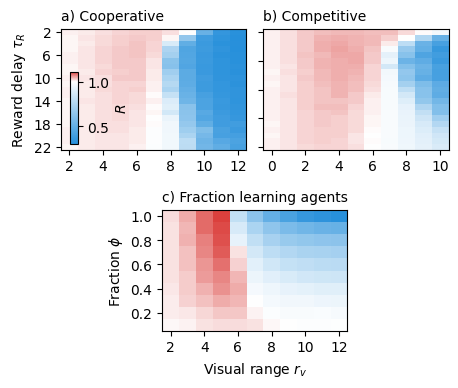

In [ ]:
fig = plt.figure(figsize=(width, 1.9*height/3*2))
gs = fig.add_gridspec(2, 4, hspace=0.5, wspace=0.2)

ax  = [fig.add_subplot(gs[0, i*2:(i+1)*2]) for i in range(2)]  # two left axes
ax_bottom    = fig.add_subplot(gs[1, 1:3])  # centered bottom axis

vmin, vmax = float(avg_cr_idx_tag.min()), float(avg_cr_frac.max())
p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)

for idx_sd, shared_depletion in enumerate([False, True]):

    ax[idx_sd].matshow(avg_cr_idx_tag[idx_sd], aspect = 'auto', cmap=cmap_div, norm=norm)
    ax[idx_sd].xaxis.set_ticks_position('bottom')

    ax[idx_sd].text(0.0, 1.05, 'b) Competitive' if shared_depletion else 'a) Cooperative',
                     transform=ax[idx_sd].transAxes, ha='left', va='bottom', c = 'k')

plt.setp(ax[:-1], 
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2], 
         yticks=np.arange(len(taus_reward))[::4], yticklabels=taus_reward[::4],
        #  xlabel = r"Visual range $r_v$"
         )
plt.setp(ax[0], ylabel = r"Reward delay $\tau_R$")
plt.setp(ax[1], yticklabels = [])

axins = ax[0].inset_axes([0.05, 0.05, 0.04, 0.6])
cbar = fig.colorbar(ax[0].images[0], cax=axins, orientation='vertical')
# cbar.outline.set_edgecolor('k')
# cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$')#, color='white')



###### FRACTION #######
vmin, vmax = float(avg_cr_frac.min()), float(avg_cr_frac.max())
p = (1.0 - vmin) / (vmax - vmin)          # normalized position of R=1 -> white

cmap_div = LinearSegmentedColormap.from_list(
    'custom_div', [(0.0, colors[0]), (p, 'white'), (1.0, colors[1])], N=250)
norm = Normalize(vmin=vmin, vmax=vmax)

ax_bottom.matshow(avg_cr_frac, cmap=cmap_div, norm=norm, aspect = 'auto')

ax_bottom.xaxis.set_ticks_position('bottom')
plt.setp(ax_bottom,
         xticks=np.arange(len(visual_ranges))[::2], xticklabels=visual_ranges[::2],
         yticks=np.arange(len(fractions))[1::2], yticklabels=np.round(fractions[1::2],1),
         xlabel="Visual range $r_v$", ylabel=r"Fraction $\phi$",
         ylim=(-0.5, len(fractions)-0.5));
ax_bottom.text(0.0, 1.05, 'c) Fraction learning agents',
                     transform=ax_bottom.transAxes, ha='left', va='bottom', c = 'k')

fig.savefig(save_dir + "CR_tauR_fraction.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

# Trajectories

# Appendix: blind search


In [ ]:
from scipy.optimize import curve_fit

def T_blind_eq18(tau, r, T_inf, B, psi=1.0):
    return T_inf * (1 - B * (r / tau) ** psi)

In [ ]:
Ls = np.linspace(50, 100, 6)
Nt, r = 10, 0.5

mftp_Ls = []
sigma_Ls = []
for l in Ls:
    mftp_Ls.append(np.load(f"data_figures_paper/blind_mftp_avg_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy"))
    sigma_Ls.append(np.load(f"data_figures_paper/blind_mftp_sem_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy"))

In [ ]:
mftp_Ls[0].shape

(19,)

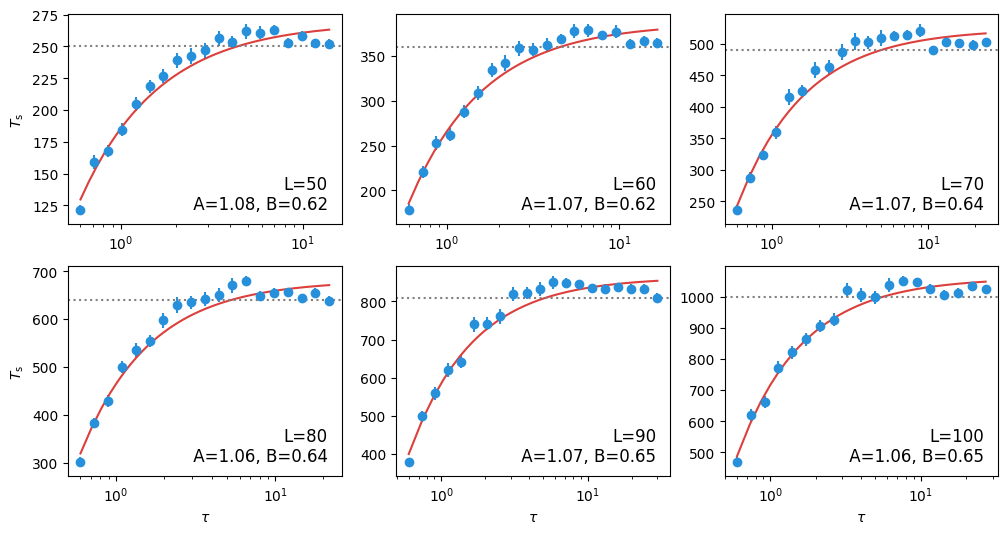

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(3*4, 2*3))

for idxL, (Tb, Sb, L) in enumerate(zip(mftp_Ls, sigma_Ls, Ls)):

    ax = axs.flatten()[idxL]

    rho = Nt / L**2
    A = 2 / (np.pi * rho)
    B_CELL = 1 / np.sqrt(np.pi * rho)
    MFP = 1 / (2 * r * rho)
    taus_b = np.logspace(np.log10(0.6), np.log10(L/3), 20)
    taus_b = taus_b[taus_b < L / 3]

    f = lambda tau, A, B: A*MFP * (1 - B * (r / tau))

    popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
    pred = f(taus_b, *popt)
    R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)


    ax.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim', c = colors[0])

    tt = np.linspace(taus_b.min(), taus_b.max(), 200)
    ax.plot(tt, T_blind_eq18(tt, r, T_inf = popt[0]*MFP, B=popt[1]), c = colors[1])

    ax.axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')

    ax.text(0.95, 0.05, f'L={L:.0f}\n A={popt[0]:.2f}, B={popt[1]:.2f}', fontsize = 12, transform=ax.transAxes, ha='right', va='bottom')    



plt.setp(axs,  xscale = 'log')
plt.setp(axs[:,0], ylabel = r"$T_{\text{s}}$")
plt.setp(axs[-1], xlabel = r"$\tau$")
plt.savefig(save_dir + "app_mftp_blind.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)


# Appendix: phase diagram

In [ ]:
from scipy.special import lambertw 

def VR_det(tau, r=0.5, B=0.73):
    tau = np.asarray(tau, dtype=float)
    out = tau * np.exp(-(np.pi / (4.0 * r)) * (1.0 - B * r / tau))
    # the expression only makes sense while the exponent stays negative
    return np.where(tau > B * r, out, np.nan)

def _k(r, B = 0.73):
    return (np.pi / (4.0 * r)) * (1.0 - B * r / tau)

def VR_prob(tau, l, r=0.5, B=0.73):
    
    _denom = lambertw(l * np.exp(_k(r, B))/ tau)

    if np.imag(_denom).any() != 0:
        print('Lambert gave back imaginary!')
    else:
        denom = np.real(_denom)
    
    return l / denom


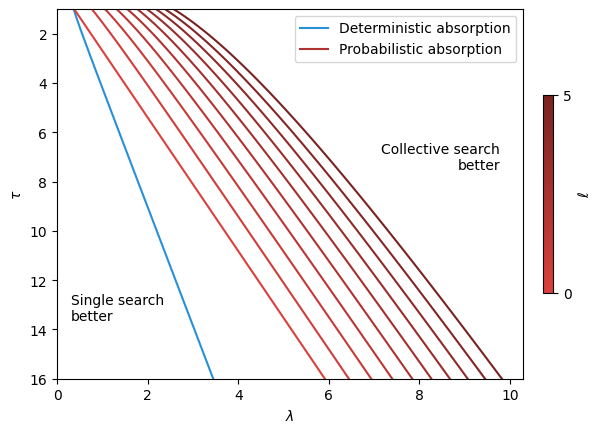

In [ ]:
fig, ax = plt.subplots()

taus = np.linspace(1, 16, 100)
VR_eff = VR_det(taus, r=0.5, B=0.73)

plt.plot(VR_eff, taus, label = 'Deterministic absorption', c = colors[0])



ls = np.linspace(0.01,5,10)


for idxl, l in enumerate(ls):
    VR_l = VR_prob(taus, l = l, r=0.5, B=0.73)
    plt.plot(VR_l, taus, c = cmap_red(np.linspace(0, 1, 10))[idxl], label = 'Probabilistic absorption' if idxl == 4 else None)



# Fills
# ax.fill_betweenx(taus, -1, VR_eff, color=colors[0], alpha=0.05)
# ax.fill_betweenx(taus, VR_eff, VR_l, color=colors[1], alpha=0.05)

plt.legend()
plt.xlabel(r'$\lambda$'); plt.ylabel(r'$\tau$'); 
# put origin in top left corner
plt.gca().invert_yaxis()
plt.ylim(taus.max(), taus.min())
plt.xlim(xmin = 0)



sm = plt.cm.ScalarMappable(cmap=cmap_red, norm=plt.Normalize(vmin=ls[0], vmax=ls[-1]))
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label(r"$\ell$")
cbar.set_ticks((0, 5))

ax.text(0.03, 0.15, 'Single search\nbetter', transform=ax.transAxes, ha='left', va='bottom', multialignment='left')
ax.text(0.95, 0.6, 'Collective search\nbetter', transform=ax.transAxes, ha='right', va='center', multialignment='right')




plt.savefig(save_dir + "app_crossover.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)



[Text(0.5, 0, 'Visual range $\\tau_R$'),
 Text(0.5, 0, 'Visual range $\\tau_R$'),
 Text(0.5, 0, 'Visual range $\\tau_R$')]

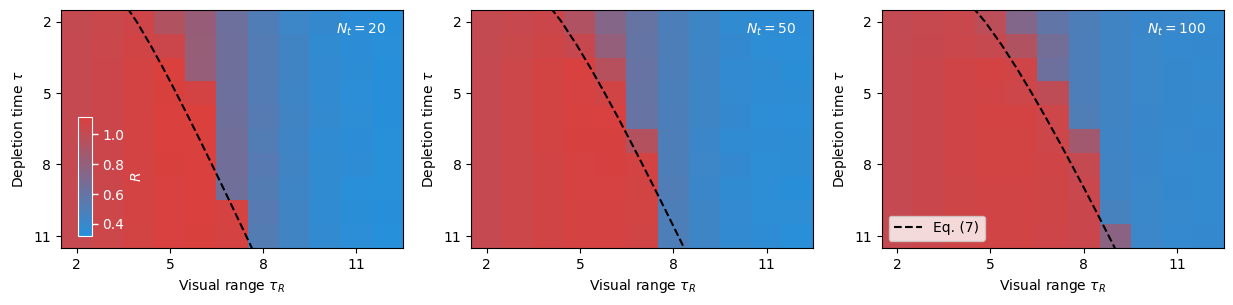

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(3*width, height))

taus = np.arange(2, 12)

# Use one global scale so colors are comparable across panels
vmin = np.min(avg_cr_idx)
vmax = np.max(avg_cr_idx)

ims = []
for idx_Nt, Nt in enumerate(Nts):
    
    im = ax[idx_Nt].matshow(avg_cr_idx[idx_Nt], vmin=vmin, vmax=vmax, aspect = 'auto', cmap=cmap_blue_red, zorder = -10)
    ims.append(im)
    ax[idx_Nt].xaxis.set_ticks_position('bottom')

    ax[idx_Nt].text(0.95, 0.95, fr"$N_t = ${Nt}", transform=ax[idx_Nt].transAxes, ha='right', va = 'top', c = 'w')

axins = ax[0].inset_axes([0.05, 0.05, 0.04, 0.5])
cbar = fig.colorbar(ims[0], cax=axins, orientation='vertical')
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(colors='white', width=1.0, length=4)
cbar.set_label(r'$R$', color='white')


taus_th = np.arange(1, 13)

ax[0].plot(VR_prob(taus_th, l = 2, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--')

ax[1].plot(VR_prob(taus_th, l = 3, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--')

ax[2].plot(VR_prob(taus_th, l = 4, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--', label = 'Eq. (7)')
ax[2].legend()

plt.setp(ax,          
         xticks=np.arange(len(visual_ranges))[::3], xticklabels=visual_ranges[::3],
        yticks=np.arange(len(taus))[::3], yticklabels=taus[::3],
         ylim = (len(taus)-0.5, -0.5),
         ylabel = r"Depletion time $\tau$",         
         )

plt.setp(ax,
         xlabel = r"Visual range $\tau_R$")


# fig.savefig(save_dir + "CR_tau.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

[<matplotlib.lines.Line2D>]

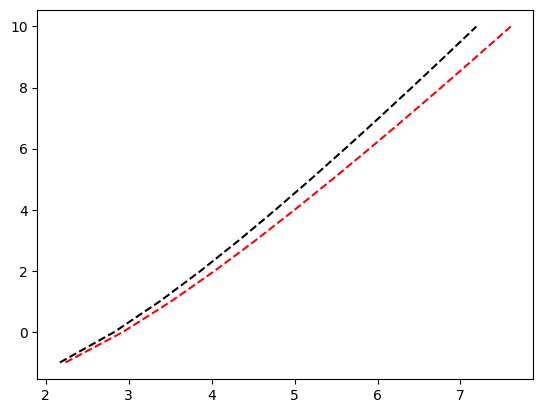

In [ ]:
plt.plot(VR_prob(taus_th, l = 4, r=0.5, B=0.64), 
           taus_th-2, c = 'k', ls = '--', label = 'Eq. (7)')

plt.plot(VR_prob(taus_th, l = 4, r=0.5, B=0.75), 
           taus_th-2, c = 'r', ls = '--', label = 'Eq. (7)')

# Appendix: phase transition analysis

In [ ]:
m   = np.load('mss_runs.npy')                      

[Text(0.5, 0, 'visual range'), Text(0, 0.5, 'fraction m>0')]

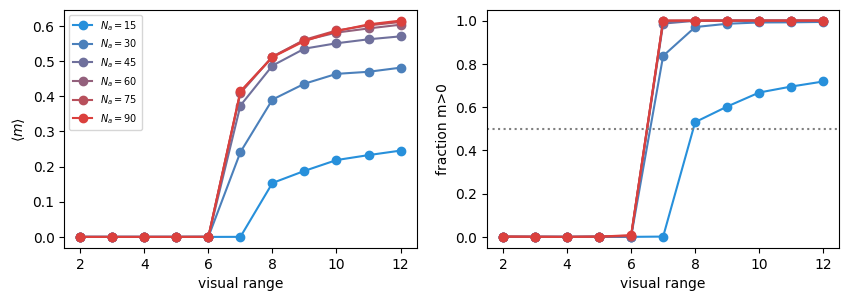

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


m   = np.load('mss_run_1_timeep_5001_nruns_8000.npy')                       # (n_sizes, n_vr, n_runs)
Nas = np.arange(15, 100, 15)
visual_ranges = np.arange(2, 13) 

rho_a = 0.02
Ls  = np.sqrt(Nas/rho_a)
n_pol = 4
M = m.reshape(*m.shape[:2], n_pol, -1)       # (n_sizes, n_vr, n_pol, runs_per_pol)

occ  = (m > 1e-9).mean(-1)                    # occupied fraction, pooled
mean = m.mean(-1)                            # <m>



# ---- Fig 1: sharp onset ----
fig, ax = plt.subplots(1, 2, figsize=(2*width, height))

colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(Nas)))
for i in range(len(Nas)):
    ax[0].plot(visual_ranges, mean[i], '-o', color=colors_from_cmap[i], label=fr'$N_a=${Nas[i]:.0f}')
    ax[1].plot(visual_ranges, occ[i],  '-o', color=colors_from_cmap[i])


ax[0].set(xlabel='visual range', ylabel=r'$\langle m\rangle$'); ax[0].legend(fontsize=7)
ax[1].axhline(.5, ls=':', c='gray'); ax[1].set(xlabel='visual range', ylabel='fraction m>0')








In [ ]:
visual_ranges[6]

np.int64(8)

''

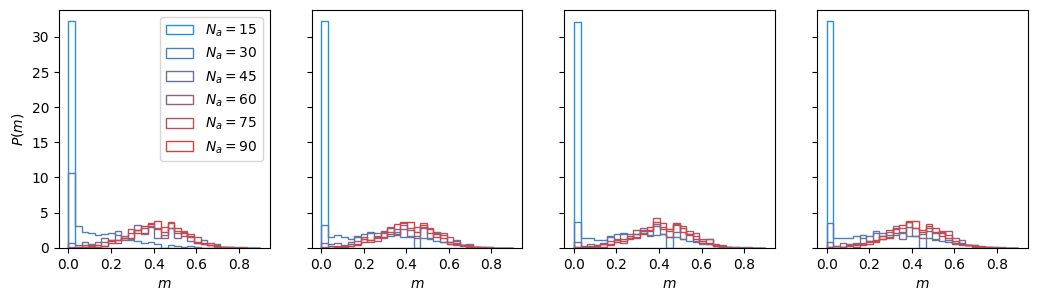

In [ ]:

Nas = np.arange(15, 100, 15)
visual_ranges = np.arange(2, 13) 

n_pol = 4
M = m.reshape(*m.shape[:2], n_pol, -1)       # (n_sizes, n_vr, n_pol, runs_per_pol)

fig, ax = plt.subplots(1, 4, figsize=(2.5*width, height), sharex = True, sharey = True)
j0 = 5

colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(Nas)))
for idxn in range(n_pol):
    for i in range(len(Nas)):
        
        ax[idxn].hist(M[i, j0, idxn].flatten(), bins=np.linspace(0, .9, 30), histtype='step',
                density=True, lw=1.6, color=colors_from_cmap[i], label=fr'$N_a=${Nas[i]:.0f}')  


plt.setp(ax, xlabel=r'$m$',)
ax[0].set( ylabel=r'$P(m)$')
ax[0].legend()
;





In [ ]:
import numpy as np, matplotlib.pyplot as plt


# Run 2
m_crossover = np.load('mss_detail_runs_all.npy').reshape(10, 11, 4, 200)[2:]
visual_ranges = np.linspace(6, 7.5, 11) 
Nas_cross = np.arange(20, 70, 5)[2:]
Ls_cross = np.sqrt(Nas_cross/0.02)

def crossing(o, th):
    o = np.maximum.accumulate(o)
    for j in range(1, len(o)):
        if o[j-1] < th <= o[j]:
            return visual_ranges[j-1] + (th-o[j-1])/(o[j]-o[j-1])*(visual_ranges[j]-visual_ranges[j-1])
    return np.nan

L = []; wm = []; ws = []; vm = []; vs = []
for i in range(Nas_cross.shape[0]):
    W = []; V = []
    for s in range(4):
        o = (m_crossover[i, :, s] > 1e-9).mean(-1)
        W.append(crossing(o, .9) - crossing(o, .1)); V.append(crossing(o, .5))
    L.append(Ls_cross[i]); wm.append(np.nanmean(W)); ws.append(np.nanstd(W)); vm.append(np.nanmean(V)); vs.append(np.nanstd(V))
L = np.array(L); wm = np.array(wm); ws = np.array(ws); vm = np.array(vm); vs = np.array(vs)
x = 1/L**2

[Text(0.5, 0, '$1/L^2$'), Text(0.5, 0, '$1/L^2$')]

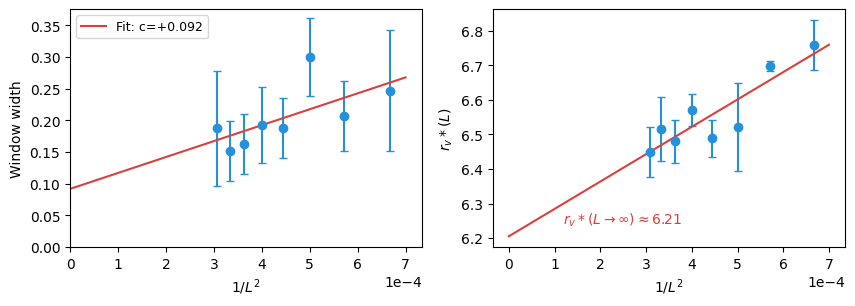

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(2*width, height))

# (a) width vs 1/L^2, fit width = a/L^2 + c using Na>=30 (drop the 2 broad small sizes)
ax[0].errorbar(x, wm, yerr=ws, fmt='o', capsize=3, c = colors[0])
A = np.vstack([x, np.ones(8)]).T
(a, c), *_ = np.linalg.lstsq(A, wm, rcond=None)
xx = np.linspace(0, x.max()*1.05, 50)
ax[0].plot(xx, a*xx + c, label=f'Fit: c={c:+.3f}', c = colors[1])
ax[0].set(ylabel='Window width')
ax[0].legend(fontsize=9); ax[0].set_xlim(0, None); ax[0].set_ylim(0, None)
ax[0].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

# (b) transition point vs 1/L^2
b = np.polyfit(x, vm, 1)
ax[1].errorbar(x, vm, yerr = vs, fmt='o', capsize=3, c = colors[0]); 
ax[1].plot(xx, np.polyval(b, xx), c = colors[1])
ax[1].set( ylabel=r'$r_v*(L)$')
ax[1].annotate(fr'$r_v*(L\rightarrow \infty) \approx ${b[1]:.2f}', (.2, .1), xycoords='axes fraction', c = colors[1])
ax[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.setp(ax, xlabel=r'$1/L^2$') 

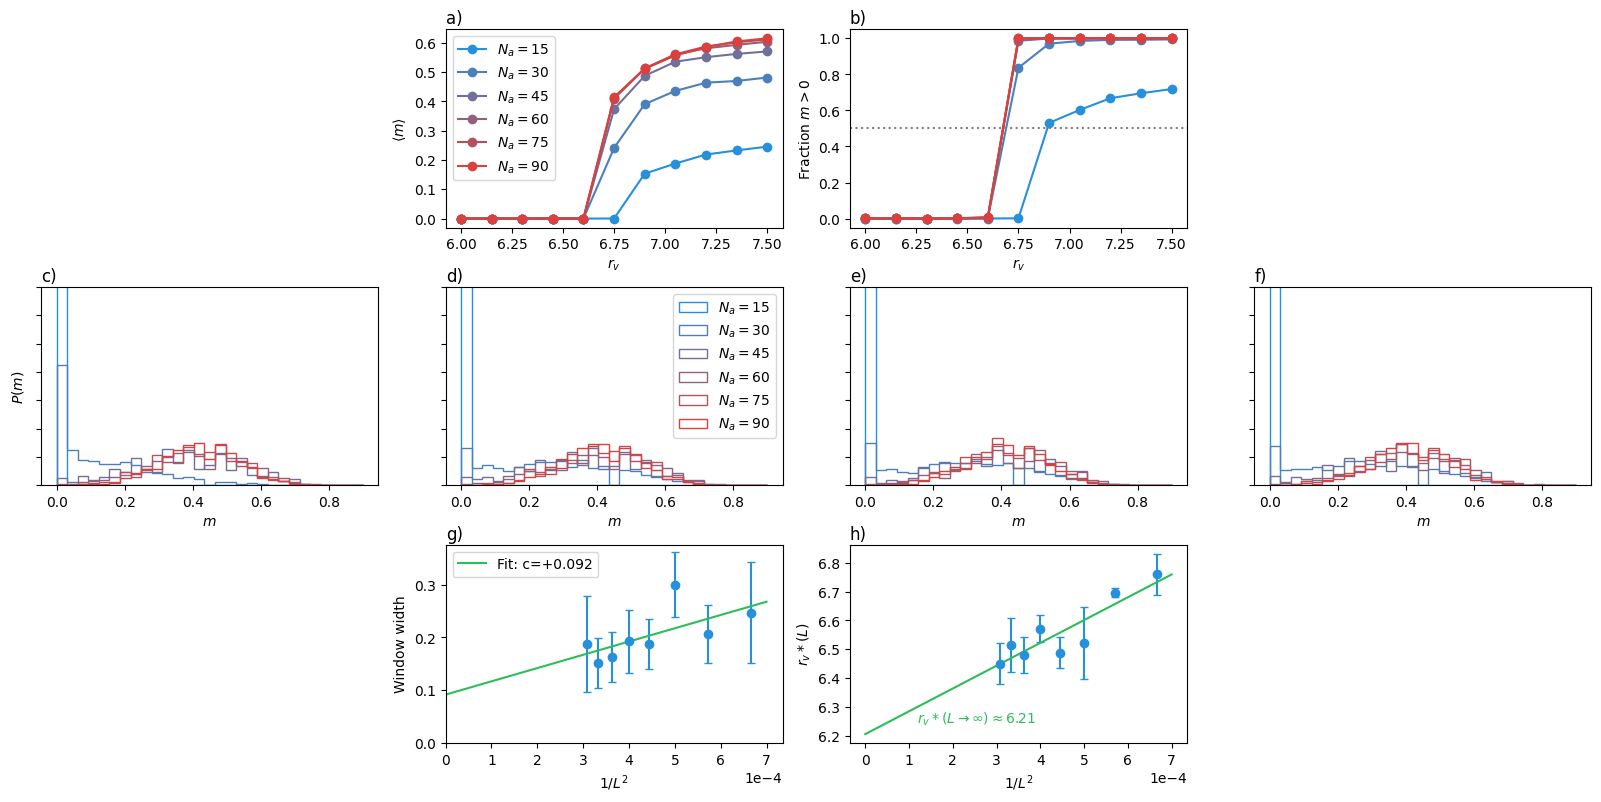

In [ ]:
fig = plt.figure(figsize=(4*width, 3*height))
gs = fig.add_gridspec(3, 4, hspace=0.3)

############ FIRST ROW ###########
ax_top = [fig.add_subplot(gs[0, i+1]) for i in range(2)]

colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(Nas)))
for i in range(len(Nas)):
    ax_top[0].plot(visual_ranges, mean[i], '-o', color=colors_from_cmap[i], label=fr'$N_a=${Nas[i]:.0f}')
    ax_top[1].plot(visual_ranges, occ[i],  '-o', color=colors_from_cmap[i])


ax_top[0].set(ylabel=r'$\langle m\rangle$'); ax[0].legend(fontsize=7)
ax_top[1].axhline(.5, ls=':', c='gray'); 
ax_top[1].set(xlabel='visual range', ylabel='Fraction $m>0$')
ax_top[0].legend()
plt.setp(ax_top, xlabel = r'$r_v$')

############### HISTOGRAMS ##################
ax_hist = [fig.add_subplot(gs[1, i]) for i in range(4)]

j0 = 5
colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(Nas)))
for idxn in range(n_pol):
    for i in range(len(Nas)):
        
        ax_hist[idxn].hist(M[i, j0, idxn].flatten(), bins=np.linspace(0, .9, 30), histtype='step',
                density=True, lw=1.6, color=colors_from_cmap[i], label=fr'$N_a=${Nas[i]:.0f}') 
        
plt.setp(ax_hist, xlabel=r'$m$', yticklabels = [], ylim = (0, 17.5))
ax_hist[0].set(ylabel=r'$P(m)$')
ax_hist[1].legend()


############### CROSSOVERs ##################
ax =  [fig.add_subplot(gs[2, i+1]) for i in range(2)]

# (a) width vs 1/L^2, fit width = a/L^2 + c using Na>=30 (drop the 2 broad small sizes)
ax[0].errorbar(x, wm, yerr=ws, fmt='o', capsize=3, c = colors[0])
A = np.vstack([x, np.ones(8)]).T
(a, c), *_ = np.linalg.lstsq(A, wm, rcond=None)
xx = np.linspace(0, x.max()*1.05, 50)
ax[0].plot(xx, a*xx + c, label=f'Fit: c={c:+.3f}', c = colors[2])
ax[0].set(ylabel='Window width')
ax[0].legend(); ax[0].set_xlim(0, None); ax[0].set_ylim(0, None)
ax[0].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

# (b) transition point vs 1/L^2
b = np.polyfit(x, vm, 1)
ax[1].errorbar(x, vm, yerr = vs, fmt='o', capsize=3, c = colors[0]); 
ax[1].plot(xx, np.polyval(b, xx), c = colors[2])
ax[1].set( ylabel=r'$r_v*(L)$')
ax[1].annotate(fr'$r_v*(L\rightarrow \infty) \approx ${b[1]:.2f}', (.2, .1), xycoords='axes fraction', c = colors[2])
ax[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.setp(ax, xlabel=r'$1/L^2$') 



for i, a in enumerate(ax_top + ax_hist + ax):    
    a.text(0, 1.01, chr(97 + i) + ")", transform=a.transAxes, fontsize=12, va='bottom', ha='left')

    
plt.savefig(save_dir + "app_no_phase_transition.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)



# Appendix: h-matrices of fractions

''

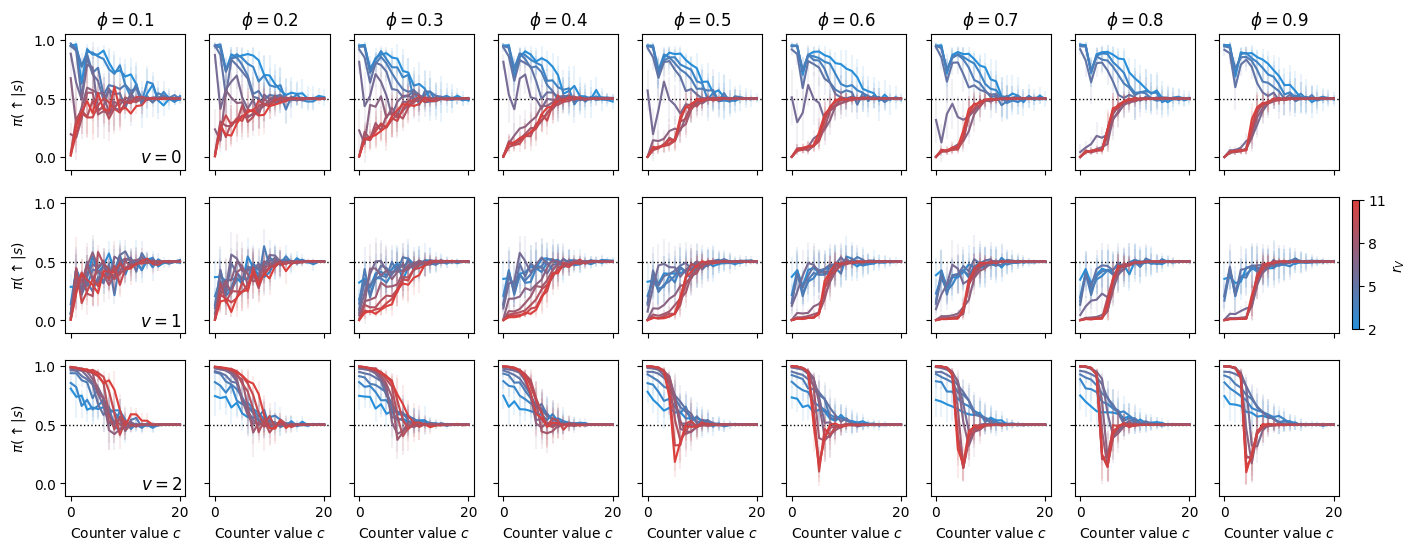

In [ ]:
out_dir_frac = '/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_7'
fractions = np.arange(0.1, 1, 0.1)
max_counter = 50
if 'agents' not in locals():
    from rl_opts.rl_framework.numba.agents import Foragers_efficient 
    agents = Foragers_efficient(num_agents, 2, np.array([max_counter, 2, 2]))

fig, axs = plt.subplots(3, len(fractions), figsize=(3*1.8*height, width*1.2), sharex=True, sharey = True)

tau = 4; tau_reward = 9 
# get colors from cmap
colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(visual_ranges)))

for idx_f, fraction in enumerate(fractions):

    axs[0, idx_f].set_title(fr"$\phi={fraction:.1f}$")

    for idx_vr, visual_range in enumerate(visual_ranges):
        
        file_name = f"_shared_{False}_frac_{fraction}_numag_{50}_L_{50}_Nt_{20}_tau_{4}_tauR_{9}_vr_{visual_ranges[idx_vr]}_ep_{10000}.npy"
                            
        h_matrix_path = os.path.join(out_dir_frac, f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        hflat = hflat[:(fraction*num_agents).astype(int)]
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if idx_f == 0 and idx_vr == 0:
                    if cone_val == 0 and rew_val == 0:
                        title = r"$v=0$"
                    if cone_val == 1 and rew_val == 0:
                        title = r"$v=1$"
                    if cone_val == 1 and rew_val == 1:
                        title = r"$v=2$"

                    if cone_val == 0 and rew_val == 1:  
                        pass
                    else:                      
                        axs[cone_val+rew_val, 0].text(0.97, 0.02, title, transform=axs[cone_val+rew_val, 0].transAxes, ha='right', va='bottom', fontsize=12)
                    
                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                

                axs[cone_val+rew_val, idx_f].plot(np.mean(p_keep[:, idxs], axis=0)[:21],
                                                color=colors_from_cmap[idx_vr]) 
                axs[cone_val+rew_val, idx_f].errorbar(np.arange(max_counter)[:21], np.mean(p_keep[:, idxs], axis=0)[:21],
                                                                yerr=np.std(p_keep[:, idxs], axis=0)[:21],
                                                                color=colors_from_cmap[idx_vr], alpha = 0.1) 
                
for a in axs.flatten():
     a.axhline(0.5, color='k', linestyle=':', lw=1, zorder = -1)
                
            

sm = plt.cm.ScalarMappable(cmap=cmap_blue_red, norm=plt.Normalize(vmin=visual_ranges[0], vmax=visual_ranges[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.005, pad=0.01)
cbar.set_label(r"$r_V$")
cbar.set_ticks(np.linspace(visual_ranges[0], visual_ranges[-1], num=4))
# cbar.set_ticklabels([str(t) for t in visual_ranges[::2]])

plt.setp(axs[:,0], ylabel = r"$\pi(\uparrow | s)$")
plt.setp(axs[-1,:], xlabel = r"Counter value $c$")
    
fig.savefig(save_dir + "app_hmats_fraction.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)
;